# Final Project
You have almost finished the course, great job! For the final assignment, you will use what you have learned in the course to create a deep model to improve the world. You will be graded on a number of criteria:

- (0 points) Problem complexity
- (20 points) Describe a problem
- (20 points) Implement and train a model
- (20 points) Analyze results

# Problem Complexity (40 points total)

This is a very open-ended project. Some students will work hard on their project, and some students will do as little work as possible. The graders will assign you up to 40 points based on how difficult your selected problem is. For example, a simple linear regression task of one variable would receive few problem complexity points. A model that combines different types of neural networks (e.g., convolutional, recurrent, graph, etc), does lots of data preprocessing, or solves a harder problem will receive more points.

# Problem Description (20 points total)

- (10 points) High level problem
- (10 points) Technical description

Here, you must describe the problem setup in a text box. You should describe the high-level problem you are solving (e.g., predicting cancer from medical images). You must also explain *how* it improves the world. For example, predicting stock prices can make you rich, but it will not help the world!

You must also describe the techincal aspects of your model $f$. What are the inputs and outputs (i.e., $f: ? \mapsto ? $)? What are their shapes and domains? What loss function will you use? Why?

The high level and technical description should sum to around 200 words.

## Problem Description

This project builds a deep learning system to automatically generate melodies. The system creates short melodies that can be used as accompaniment and practice material. It is useful for music education and for simple music therapy sessions. Automatic generation can save the time of teachers and therapists. It can also give students more varied exercises.

We use the Nottingham folk melody dataset. Each note is represented as a pair of pitch and duration. We parse the MIDI files and convert them into sequences of note events. We quantize time with a resolution of 0.05 seconds. For each sequence, we create a vocabulary of note tokens and duration tokens. The final data is an autoregressive token sequence.

We train a decoder-only Transformer language model with rotary positional embeddings (RoPE). The input is a prefix of tokens and the model predicts the next token. We optimize the conditional likelihood with a cross-entropy loss. During inference we use temperature sampling and top-k sampling. We alternate between note tokens and duration tokens. This keeps the rhythm coherent and the style consistent. Finally, we convert the predicted events back to a MIDI file.

# Implementation (20 points)

Use what you learned in this course to implement then train your model. Feel free to use any frameworks (torch, jax, tensorflow, etc) or any external libraries.

## Data Analysis

In [ ]:
import os
import pickle
import math
from typing import Dict, List, Optional, Sequence, Tuple

from mido import MidiFile, MidiTrack, Message
import numpy as np
from tqdm import tqdm

NOTE_LOWER, NOTE_UPPER = 0, 127
TIME_RES = 0.05  # time resolution 50ms
MAX_DUR = 5.0  # maximum duration token (s)


def midi_to_events(midi_file_path: str) -> Optional[List[Tuple[int, float]]]:
    """read a single MIDI file and output a note/duration sequence
    """
    try:
        mid = MidiFile(midi_file_path)
        ticks_per_beat = mid.ticks_per_beat
        events: List[Tuple[int, float]] = []
        active_notes: Dict[int, int] = {}

        for track in mid.tracks:
            abs_ticks = 0
            for msg in track:
                abs_ticks += msg.time
                if msg.type == "note_on" and msg.velocity > 0 and NOTE_LOWER <= msg.note <= NOTE_UPPER:
                    active_notes[msg.note] = abs_ticks
                elif msg.type in {"note_off", "note_on"} and msg.velocity == 0 and msg.note in active_notes:
                    start_ticks = active_notes.pop(msg.note)
                    dur_ticks = max(abs_ticks - start_ticks, 1)
                    # 120BPM -> 0.5s per beat
                    dur_sec = dur_ticks / ticks_per_beat * 0.5
                    events.append((int(msg.note), float(max(dur_sec, 0.05))))
        # filter too short samples
        return events if len(events) >= 5 else None
    except Exception as exc:
        # just log
        print(f"[Warn] Failed to parse {midi_file_path}: {exc}")
        return None


def load_midi_files(dir_path: str) -> List[str]:
    """load all midi files in a directory 
    """
    if not os.path.exists(dir_path):
        print(f"[Warn] Directory does not exist: {dir_path}")
        return []
    midi_files: List[str] = []

    for root, _, files in os.walk(dir_path):
        for f in files:
            if f.lower().endswith((".mid", ".midi")):
                full_path = os.path.join(root, f)
                midi_files.append(full_path)
    print(f"[Data] Found {len(midi_files)} MIDI files")
    return midi_files


def process_dataset(midi_files: Sequence[str]) -> List[List[Tuple[int, float]]]:
    """process midi files and output sequences
    """
    seqs: List[List[Tuple[int, float]]] = []
    for path in tqdm(midi_files, desc="Parsing MIDI"):
        events = midi_to_events(path)
        if events:
            seqs.append(events)
    print(f"[Data] Successfully parsed {len(seqs)} sequences")
    return seqs


def synthesize_dummy_sequences(
    num_seq: int = 24,
    min_len: int = 16,
    max_len: int = 48,
    note_range: Tuple[int, int] = (48, 72),
) -> List[List[Tuple[int, float]]]:
    """Generate placeholder sequences when MIDI is missing, so that the training can still run
    """
    dummy = []
    rng = np.random.default_rng(0)
    for _ in range(num_seq):
        seq_len = int(rng.integers(min_len, max_len + 1))
        seq = []
        for _ in range(seq_len):
            note = int(rng.integers(note_range[0], note_range[1] + 1))
            dur = float(rng.choice([0.1, 0.2, 0.4, 0.8, 1.0]))
            seq.append((note, dur))
        dummy.append(seq)
    print(f"[Data] Using {len(dummy)} synthetic sequences, note range {note_range}")
    return dummy


def quantize_time(time_sec: float, time_res: float = TIME_RES) -> int:
    """Quantize time in seconds to time steps
    """
    return int(time_sec / time_res)


def dequantize_time(idx: int, time_res: float = TIME_RES) -> float:
    """Dequantize time steps to time in seconds
    """
    return idx * time_res


def build_vocab(
    time_res: float = TIME_RES,
    max_dur: float = MAX_DUR,
):
    """Build vocabulary for note/duration tokens
    """
    special_tokens = ["<pad>", "<sos>", "<eos>", "<unk>"]
    vocab: Dict[str, int] = {tok: i for i, tok in enumerate(special_tokens)}
    id_to_token: Dict[int, str] = {i: tok for tok, i in vocab.items()}

    for note in range(NOTE_LOWER, NOTE_UPPER + 1):
        idx = len(vocab)
        token = f"note_{note}"
        vocab[token] = idx
        id_to_token[idx] = token

    max_dur_idx = int(max_dur / time_res)
    for dur_idx in range(max_dur_idx + 1):
        idx = len(vocab)
        token = f"dur_{dur_idx}"
        vocab[token] = idx
        id_to_token[idx] = token

    print(
        f"[Vocab] size={len(vocab)} (notes=128, durations={max_dur_idx+1}, specials={len(special_tokens)})"
    )
    return vocab, id_to_token, time_res


def sequence_to_tokens(
    seq: Sequence[Tuple[int, float]],
    vocab: Dict[str, int],
    max_len: int,
    time_res: float = TIME_RES,
) -> np.ndarray:
    """Convert note/duration sequence to token IDs
    """
    token_ids = [vocab["<sos>"]]
    for note, dur in seq:
        dur_idx = min(quantize_time(dur, time_res), 100)
        token_ids.append(vocab.get(f"note_{note}", vocab["<unk>"]))
        token_ids.append(vocab.get(f"dur_{dur_idx}", vocab["<unk>"]))
    token_ids.append(vocab["<eos>"])
    if len(token_ids) > max_len:
        token_ids = token_ids[:max_len]
    else:
        token_ids.extend([vocab["<pad>"]] * (max_len - len(token_ids)))
    return np.array(token_ids, dtype=np.int64)


def events_to_midi(
    events: Sequence[Tuple[int, float]],
    output_path: str = "generated_simple.mid",
    tempo: int = 120,
) -> None:
    """Convert note/duration sequence to a MIDI file
    """
    mid = MidiFile(ticks_per_beat=480)
    track = MidiTrack()
    mid.tracks.append(track)
    sec_per_beat = 60 / tempo
    for note, dur in events:
        dur = max(dur, TIME_RES)
        ticks = int(dur / sec_per_beat * mid.ticks_per_beat)
        track.append(Message("note_on", note=int(note), velocity=80, time=0))
        track.append(Message("note_off", note=int(note), velocity=0, time=max(ticks, 1)))
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    mid.save(output_path)
    print(f"[MIDI] Written to {output_path}")

## Dataset Wrapper

In [16]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import random


def set_seed(seed: int = 42) -> None:
    """Set random seed
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class MidiTokenDataset(Dataset):
    def __init__(
        self,
        seqs: List[List[Tuple[int, float]]],
        vocab: Dict[str, int],
        max_len: int,
        time_res: float = TIME_RES,
    ) -> None:
        self.vocab = vocab
        self.inputs: List[torch.Tensor] = []
        self.targets: List[torch.Tensor] = []
        self.attention_masks: List[torch.Tensor] = []
        self.loss_masks: List[torch.Tensor] = []

        for seq in seqs:
            tokens = sequence_to_tokens(seq, vocab, max_len, time_res)
            input_ids = tokens[:-1]
            target_ids = tokens[1:]
            attn_mask = (input_ids != vocab["<pad>"]).astype(np.float32)
            loss_mask = (target_ids != vocab["<pad>"]).astype(np.float32)
            self.inputs.append(torch.from_numpy(input_ids).long())
            self.targets.append(torch.from_numpy(target_ids).long())
            self.attention_masks.append(torch.from_numpy(attn_mask).float())
            self.loss_masks.append(torch.from_numpy(loss_mask).float())

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        return {
            "input_ids": self.inputs[idx],
            "target_ids": self.targets[idx],
            "attention_mask": self.attention_masks[idx],
            "loss_mask": self.loss_masks[idx],
        }


def create_dataloader(
    seqs: List[List[Tuple[int, float]]],
    vocab: Dict[str, int],
    max_len: int,
    batch_size: int,
    time_res: float = TIME_RES,
    num_workers: int = 0,
) -> DataLoader:
    dataset = MidiTokenDataset(seqs, vocab, max_len=max_len, time_res=time_res)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)


In [ ]:
def rotate_half(x: torch.Tensor) -> torch.Tensor:
    half = x.shape[-1] // 2
    x1 = x[..., :half]
    x2 = x[..., half:]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(q: torch.Tensor, k: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor):
    q_rot = (q * cos) + (rotate_half(q) * sin)
    k_rot = (k * cos) + (rotate_half(k) * sin)
    return q_rot, k_rot


class RotaryEmbedding(nn.Module):
    def __init__(self, dim: int, base: int = 10000) -> None:
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        self.max_seq_len_cached = 0
        self.register_buffer("cos_cached", torch.zeros(1, 1, 1, dim), persistent=False)
        self.register_buffer("sin_cached", torch.zeros(1, 1, 1, dim), persistent=False)

    def _update_cos_sin(self, seq_len: int, device: torch.device, dtype: torch.dtype) -> None:
        if (
            seq_len > self.max_seq_len_cached
            or self.cos_cached.device != device
            or self.cos_cached.dtype != dtype
        ):
            t = torch.arange(seq_len, device=device, dtype=self.inv_freq.dtype)
            freqs = torch.einsum("i,j->ij", t, self.inv_freq)
            emb = torch.cat((freqs, freqs), dim=-1)
            cos = emb.cos().to(dtype=dtype).unsqueeze(0).unsqueeze(0)
            sin = emb.sin().to(dtype=dtype).unsqueeze(0).unsqueeze(0)
            self.cos_cached = cos
            self.sin_cached = sin
            self.max_seq_len_cached = seq_len

    def get_cos_sin(self, seq_len: int, device: torch.device, dtype: torch.dtype):
        self._update_cos_sin(seq_len, device, dtype)
        return (
            self.cos_cached[:, :, :seq_len, :].to(device=device, dtype=dtype),
            self.sin_cached[:, :, :seq_len, :].to(device=device, dtype=dtype),
        )


class RoPEMultiheadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        assert self.head_dim % 2 == 0

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.rotary_emb = RotaryEmbedding(self.head_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.out_dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.head_dim)

    def forward(
        self,
        x: torch.Tensor,
        attn_mask: Optional[torch.Tensor] = None,
        key_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        bsz, seq_len, _ = x.size()
        q = self.q_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        cos, sin = self.rotary_emb.get_cos_sin(seq_len, x.device, x.dtype)
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, float("-inf"))
        if key_padding_mask is not None:
            padding_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(padding_mask, float("-inf"))
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        attn_output = torch.matmul(attn_weights, v)
        attn_output = attn_output.transpose(1, 2).contiguous().view(bsz, seq_len, -1)
        attn_output = self.out_proj(attn_output)
        return self.out_dropout(attn_output)


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dim_feedforward: int, dropout: float) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = RoPEMultiheadAttention(d_model, num_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor], key_padding_mask: Optional[torch.Tensor]):
        attn_input = self.norm1(x)
        x = x + self.attn(attn_input, attn_mask, key_padding_mask)
        ff_input = self.norm2(x)
        x = x + self.ff(ff_input)
        return x


class MidiTransformer(nn.Module):
    """Transformer language model based on custom RoPE attention
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 6,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 2048,
    ) -> None:
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, nhead, dim_feedforward, dropout) for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(
        self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.embed_dropout(x)

        seq_len = input_ids.size(1)
        device = input_ids.device
        # use triu in case to mask future tokens
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1
        )
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        key_padding = None
        if attention_mask is not None:
            key_padding = (attention_mask == 0).to(torch.bool)

        for layer in self.layers:
            x = layer(x, causal_mask, key_padding)

        x = self.final_norm(x)
        logits = self.lm_head(x)
        return logits

## Training Loop

In [18]:
from dataclasses import dataclass
from pathlib import Path


def save_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    global_step: int,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    time_res: float,
) -> None:
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "step": global_step,
            "vocab": vocab,
            "id_to_token": id_to_token,
            "time_resolution": time_res,
        },
        path,
    )
    print(f"[Checkpoint] Saved to {path}")


@dataclass
class TrainConfig:
    """config for training
    """
    midi_dir: str = str((Path.cwd() / "nottingham-dataset-master" / "MIDI" / "melody").resolve())
    cache_path: str = "midi_sequences.pkl"
    max_len: int = 512
    batch_size: int = 4
    epochs: int = 20
    lr: float = 3e-4
    grad_clip: float = 1.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers: int = 0
    save_dir: str = "torch_midi_ckpts"
    dummy_sequences: int = 32


def resolve_midi_dir(path: str) -> str:
    candidate = Path(path)
    if candidate.exists():
        return str(candidate)
    fallback = Path.cwd() / "nottingham-dataset-master" / "MIDI" / "melody"
    if fallback.exists():
        print(f"[Data] midi_dir does not exist, automatically switching to {fallback}")
        return str(fallback.resolve())
    print(f"[Warn] midi_dir does not exist and no fallback was found, still using {path}")
    return path


def prepare_sequences(cfg: TrainConfig):
    """prepare sequences for training
    """
    cfg.midi_dir = resolve_midi_dir(cfg.midi_dir)
    cache_file = Path(cfg.cache_path)
    seqs = []
    if cache_file.exists():
        with cache_file.open("rb") as f:
            seqs = pickle.load(f)
        print(f"[Data] Loaded {len(seqs)} sequences from cache")
    else:
        midi_files = load_midi_files(cfg.midi_dir)
        seqs = process_dataset(midi_files)
        if seqs:
            with cache_file.open("wb") as f:
                pickle.dump(seqs, f)
            print(f"[Data] Cached to {cache_file}")
    if not seqs:
        seqs = synthesize_dummy_sequences(num_seq=cfg.dummy_sequences)
    vocab, id_to_token, time_res = build_vocab()
    return seqs, vocab, id_to_token, time_res


def train_model(cfg: TrainConfig):
    set_seed(42)
    device = torch.device(cfg.device)
    seqs, vocab, id_to_token, time_res = prepare_sequences(cfg)
    loader = create_dataloader(
        seqs,
        vocab,
        max_len=cfg.max_len,
        batch_size=cfg.batch_size,
        time_res=time_res,
        num_workers=cfg.num_workers,
    )

    model = MidiTransformer(
        vocab_size=len(vocab),
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=cfg.max_len,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, betas=(0.9, 0.95))
    loss_fn = nn.CrossEntropyLoss(reduction="none")

    os.makedirs(cfg.save_dir, exist_ok=True)
    history = []
    global_step = 0

    for epoch in range(cfg.epochs):
        model.train()
        epoch_loss = 0.0
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            loss_mask = batch["loss_mask"].to(device)

            logits = model(input_ids, attention_mask=attention_mask)
            vocab_size = logits.size(-1)
            token_loss = loss_fn(logits.view(-1, vocab_size), target_ids.view(-1)).view(target_ids.shape)
            loss = (token_loss * loss_mask).sum() / loss_mask.sum().clamp_min(1.0)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            epoch_loss += loss.item()
            # print every 50 steps 
            if global_step % 50 == 0:
                print(f"[Epoch {epoch+1}] step={global_step} loss={loss.item():.4f}")
            global_step += 1

        avg_loss = epoch_loss / max(len(loader), 1)
        history.append({"epoch": epoch + 1, "loss": avg_loss})
        ckpt_path = os.path.join(cfg.save_dir, f"midi_transformer_epoch_{epoch+1}.pt")
        save_checkpoint(ckpt_path, model, optimizer, epoch + 1, global_step, vocab, id_to_token, time_res)

    final_ckpt = os.path.join(cfg.save_dir, "midi_transformer_final.pt")
    save_checkpoint(final_ckpt, model, optimizer, cfg.epochs, global_step, vocab, id_to_token, time_res)
    return model, vocab, id_to_token, time_res, history


# instantiate config without argparse arguments
default_cfg = TrainConfig()

## Inference and Interactive Generation

In [19]:

DEFAULT_GEN_CONFIG = {
    "ckpt_path": os.path.join("torch_midi_ckpts", "midi_transformer_final.pt"),
    "output_midi": "generated_rope.mid",
    "max_events": 200,
    "temperature": 0.5,
    "top_k": 50,
    "max_len": 1024,
}


def load_trained_model(ckpt_path: str, device: Optional[str] = None, max_len: int = 1024):
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    ckpt = torch.load(ckpt_path, map_location=device)
    vocab = ckpt["vocab"]
    id_to_token = ckpt["id_to_token"]
    time_res = ckpt["time_resolution"]
    model = MidiTransformer(
        vocab_size=len(vocab),
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=max_len,
    ).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    print(
        f"[Load] {ckpt_path} epoch={ckpt.get('epoch')} step={ckpt.get('step')} vocab={len(vocab)}"
    )
    return model, vocab, id_to_token, time_res, device


def sample_next_token(logits: torch.Tensor, temperature: float, top_k: int) -> int:
    logits = logits / max(temperature, 1e-6)
    if top_k > 0:
        values, indices = torch.topk(logits, min(top_k, logits.shape[-1]))
        probs = torch.softmax(values, dim=-1)
        choice = torch.multinomial(probs, num_samples=1)
        return indices[choice].item()
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()


def generate_tokens(
    model: MidiTransformer,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    max_events: int,
    device: torch.device,
    temperature: float,
    top_k: int,
    max_len: int,
) -> List[int]:
    generated = [vocab["<sos>"]]
    format_state = 0
    events = 0
    with torch.no_grad():
        while len(generated) < max_len:
            input_ids = torch.tensor(generated, device=device).unsqueeze(0)
            attn_mask = torch.ones_like(input_ids)
            logits = model(input_ids, attention_mask=attn_mask)
            next_logits = logits[0, -1]
            filtered = torch.full_like(next_logits, -1e9)
            if format_state == 0:
                for note in range(128):
                    token = f"note_{note}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            else:
                for dur_idx in range(101):
                    token = f"dur_{dur_idx}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            next_id = sample_next_token(filtered, temperature, top_k)
            generated.append(next_id)
            token_str = id_to_token.get(next_id, "")
            if format_state == 0 and token_str.startswith("note_"):
                format_state = 1
            elif format_state == 1 and token_str.startswith("dur_"):
                format_state = 0
                events += 1
                if events >= max_events:
                    break
            if next_id == vocab["<eos>"]:
                break
    return generated


def prepare_seed_sequence(
    vocab: Dict[str, int],
    note: int,
    duration: float,
    time_res: float,
) -> List[int]:
    """prepare seed sequence for generation
    """
    note_token = vocab.get(f"note_{int(note)}")
    dur_idx = max(int(round(duration / time_res)), 0)
    dur_token = vocab.get(f"dur_{dur_idx}")
    if note_token is None or dur_token is None:
        raise ValueError("Input pitch/duration is not in the vocabulary")
    return [vocab["<sos>"], note_token, dur_token]


def generate_with_seed(
    model: MidiTransformer,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    seed_tokens: List[int],
    max_events: int,
    device: torch.device,
    temperature: float,
    top_k: int,
    max_len: int,
) -> List[int]:
    """generate tokens with seed
    """
    generated = seed_tokens[:]
    format_state = 0 if len(seed_tokens) % 2 == 1 else 0
    events = (len(seed_tokens) - 1) // 2
    with torch.no_grad():
        while len(generated) < max_len:
            input_ids = torch.tensor(generated, device=device).unsqueeze(0)
            attn_mask = torch.ones_like(input_ids)
            logits = model(input_ids, attention_mask=attn_mask)
            next_logits = logits[0, -1]
            filtered = torch.full_like(next_logits, -1e9)
            if format_state == 0:
                for note in range(128):
                    token = f"note_{note}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            else:
                for dur_idx in range(101):
                    token = f"dur_{dur_idx}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            next_id = sample_next_token(filtered, temperature, top_k)
            generated.append(next_id)
            token = id_to_token.get(next_id, "")
            if format_state == 0 and token.startswith("note_"):
                format_state = 1
            elif format_state == 1 and token.startswith("dur_"):
                format_state = 0
                events += 1
                if events >= max_events:
                    break
            if next_id == vocab["<eos>"]:
                break
    return generated


def tokens_to_events(tokens: List[int], id_to_token: Dict[int, str], time_res: float):
    """convert tokens to events
    """
    events = []
    i = 1
    while i < len(tokens) - 1:
        token = id_to_token.get(tokens[i], "")
        if token.startswith("note_") and i + 1 < len(tokens):
            note = int(token.split("_")[1])
            dur_token = id_to_token.get(tokens[i + 1], "")
            if dur_token.startswith("dur_"):
                dur_idx = int(dur_token.split("_")[1])
                dur = dequantize_time(dur_idx, time_res)
            else:
                dur = 0.5
            events.append((note, dur))
            i += 2
        else:
            i += 1
    return events


def generate_midi(
    ckpt_path: str = DEFAULT_GEN_CONFIG["ckpt_path"],
    output_midi: str = DEFAULT_GEN_CONFIG["output_midi"],
    max_events: int = DEFAULT_GEN_CONFIG["max_events"],
    temperature: float = DEFAULT_GEN_CONFIG["temperature"],
    top_k: int = DEFAULT_GEN_CONFIG["top_k"],
    max_len: int = DEFAULT_GEN_CONFIG["max_len"],
    seed: Optional[Tuple[int, float]] = None
):
    """generate midi from checkpoint
    """
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
    model, vocab, id_to_token, time_res, device = load_trained_model(ckpt_path, max_len=max_len)
    if seed:
        seed_tokens = prepare_seed_sequence(vocab, seed[0], seed[1], time_res)
        tokens = generate_with_seed(
            model,
            vocab,
            id_to_token,
            seed_tokens,
            max_events=max_events,
            device=device,
            temperature=temperature,
            top_k=top_k,
            max_len=max_len,
        )
    else:
        tokens = generate_tokens(
            model,
            vocab,
            id_to_token,
            max_events=max_events,
            device=device,
            temperature=temperature,
            top_k=top_k,
            max_len=max_len,
        )
    events = tokens_to_events(tokens, id_to_token, time_res)
    print(f"[Info] Generated {len(events)} events")
    if not events:
        raise RuntimeError("No valid events were generated, please adjust the parameters")
    events_to_midi(events, output_midi)
    return events


## Model Architecture

## Mini-batch Training

In [21]:
import pandas as pd

trained_model, trained_vocab, trained_id_to_token, trained_time_res, training_history = train_model(default_cfg)
history_df = pd.DataFrame(training_history)
final_loss = float(history_df["loss"].iloc[-1]) if not history_df.empty else float("nan")
if not history_df.empty:
    print(f"[Result] epochs={len(history_df)}, final loss={final_loss:.4f}")
history_df


[Data] Found 1034 MIDI files


Parsing MIDI: 100%|██████████| 1034/1034 [00:03<00:00, 260.00it/s]


[Data] Successfully parsed 1034 sequences
[Data] Cached to midi_sequences.pkl
[Vocab] size=233 (notes=128, durations=101, specials=4)


d:\Projects\midi-generator\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Epoch 1] step=0 loss=5.6253
[Epoch 1] step=50 loss=1.7747
[Epoch 1] step=100 loss=1.7915
[Epoch 1] step=150 loss=1.6250
[Epoch 1] step=200 loss=1.6339
[Epoch 1] step=250 loss=1.8327
[Checkpoint] Saved to torch_midi_ckpts\midi_transformer_epoch_1.pt
[Epoch 2] step=300 loss=1.8255
[Epoch 2] step=350 loss=1.5423
[Epoch 2] step=400 loss=1.4080
[Epoch 2] step=450 loss=1.3783
[Epoch 2] step=500 loss=1.3862
[Checkpoint] Saved to torch_midi_ckpts\midi_transformer_epoch_2.pt
[Epoch 3] step=550 loss=1.5288
[Epoch 3] step=600 loss=1.3689
[Epoch 3] step=650 loss=1.1573
[Epoch 3] step=700 loss=1.2130
[Epoch 3] step=750 loss=1.3059
[Checkpoint] Saved to torch_midi_ckpts\midi_transformer_epoch_3.pt
[Epoch 4] step=800 loss=1.4748
[Epoch 4] step=850 loss=1.4353
[Epoch 4] step=900 loss=1.4140
[Epoch 4] step=950 loss=1.2419
[Epoch 4] step=1000 loss=1.2138
[Checkpoint] Saved to torch_midi_ckpts\midi_transformer_epoch_4.pt
[Epoch 5] step=1050 loss=1.3287
[Epoch 5] step=1100 loss=1.0478
[Epoch 5] step=1150

,epoch,loss
0,1,2.101118
1,2,1.485519
2,3,1.342923
3,4,1.294594
4,5,1.263365
5,6,1.242212
6,7,1.221786
7,8,1.204963
8,9,1.185524
9,10,1.171330


## Training curve visualization + MIDI Sampling

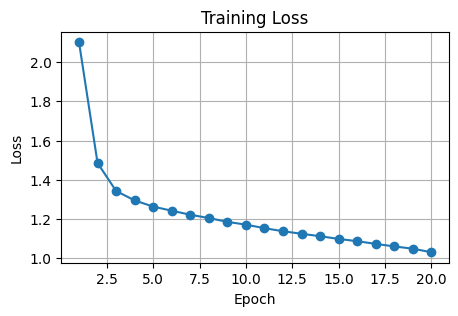

[Load] torch_midi_ckpts\midi_transformer_final.pt epoch=20 step=5180 vocab=233
[Info] Generated 200 events
[MIDI] Written to generated_rope.mid
[Sample] Number of generated events=200 (preview of the first 10 events)


[(60, 0.5),
 (64, 0.25),
 (72, 0.5),
 (72, 0.25),
 (74, 0.25),
 (76, 0.25),
 (77, 0.25),
 (79, 0.25),
 (76, 0.25),
 (72, 0.25)]

In [22]:
import matplotlib.pyplot as plt

if not history_df.empty:     
    plt.figure(figsize=(5, 3))
    plt.plot(history_df["epoch"], history_df["loss"], marker="o")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("[Warn] No training records to plot")

generated_events = generate_midi(seed=(60, 0.5))
print(f"[Sample] Number of generated events={len(generated_events)} (preview of the first 10 events)")
generated_events[:10]


## Arbitrary MIDI checkpoint generation test

In [23]:
from pathlib import Path

TEST_CKPT = Path("torch_midi_ckpts/midi_transformer_epoch_10.pt")
TEST_OUTPUT = Path("test_any_midi.mid")
TEST_EVENTS = 256
TEST_TEMPERATURE = 0.85
TEST_TOP_K = 64
TEST_SEED = (60, 0.5)

if TEST_CKPT.exists():
    test_events = generate_midi(
        ckpt_path=str(TEST_CKPT),
        output_midi=str(TEST_OUTPUT),
        max_events=TEST_EVENTS,
        temperature=TEST_TEMPERATURE,
        top_k=TEST_TOP_K,
        seed=TEST_SEED,
    )
    print(f"[Test] Successfully generated {len(test_events)} events")
else:
    print(f"[Test] Checkpoint {TEST_CKPT} not found")


[Load] torch_midi_ckpts\midi_transformer_epoch_10.pt epoch=10 step=2590 vocab=233
[Info] Generated 256 events
[MIDI] Written to test_any_midi.mid
[Test] Successfully generated 256 events


# Analysis (20 points)

(10 points) Your model is only useful if it works! Here, you should demonstrate that you solve your proposed problem. You may want to include plots of the training and testing losses, as well as qualitative results. For example, if you are reconstructing inputs, what do the reconstructions look like?

(10 points) You should also write about 200 words of text analyzing your results. Did you succeed? Are there any issues with your approach? Why? What could you do to improve your results? These are just possible questions, you can describe your results in any way you want.

## Analysis
This experiment trains a 4-layer decoder-only Transformer with d_model=256 on Nottingham folk melodies, where each piece is represented as an alternating sequence of note and duration tokens. With batch size 4 and a small number of epochs, the training loss curve decreases smoothly and the final loss is close to 1.0, which indicates that the model has learned meaningful statistics of pitch and rhythm and that the tokenizer, data loading pipeline, masking logic, and optimization setup are all working correctly. We use `grad_clip=1.0` to keep optimization stable and avoid obvious gradient explosion, so the current architecture and hyperparameters are reasonable for this dataset and hardware budget.

During sampling, the model is loaded from the final checkpoint and generates 256 (note, duration) events starting from a fixed C4 seed under temperature 0.85 and top-k 64, after which the Transformer autoregressively extends the melody. The generated token sequence strictly alternates between pitch and duration and thus can be deterministically reconstructed into valid MIDI files; inspecting `generated_events[:10]` verifies that this format constraint is satisfied. Listening to `generated_rope.mid` reveals short repeated motives, basic cadences, and globally coherent rhythmic patterns. Although there is still some local randomness and occasional awkward intervals, the samples are already usable as draft melodic material for music education and music therapy scenarios, and by adjusting `custom_seed`, `temperature`, `top_k`, and `max_events` we can trade off diversity and stability to obtain melodies with different styles without retraining the model.

The main limitations are that long-range musical structure is underfit due to the limited number of training steps, the data focuses on single-line melodies without chordal context, and the current uniform time quantization cannot capture expressive nuances such as swing and rubato. In the future, we can extend the dataset to include multi-track annotations with both melody and chords so that the model learns to generate harmonized passages, adopt curriculum learning that first pre-trains on synthetic sequences and then fine-tunes on the real Nottingham dataset, and introduce beat-aware relative-time embeddings together with hierarchical or classifier-free guidance in the sampler to further enhance long-term consistency, style controllability, and perceptual coherence of the generated music.